In [0]:
import mlflow
import mlflow.sklearn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error


In [0]:
df = spark.read.table("liquid_telecom.gold.g_fact_subscriptions_revenue")

## **ML Flow 1 : Revenue Prediction(Regression)**

In [0]:
features = [
    "total_one_off_price_usd",
    "total_recurring_price_usd",
    "is_recurring_flag"
]

target = "total_revenue_usd"


### **Convert Spark To Pandas**

In [0]:
pdf = df.select(features + [target]).toPandas()
pdf = pdf.dropna()

### **Train/Test Split**

In [0]:
X = pdf[features]
y = pdf[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### **Train Linear Regression Model**

In [0]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

### **Prediction And Metric**

In [0]:
y_pred = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse


np.float64(3.0987277785168865e-11)

In [0]:
mlflow.set_experiment("/liquid_telecom_mlflow")

with mlflow.start_run(run_name="Revenue_Prediction_Linear_Regression"):
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("rmse", rmse)
    mlflow.sklearn.log_model(lr_model, "linear_regression_model")


2026/01/30 14:19:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [0]:
y_pred = lr_model.predict(X_test)


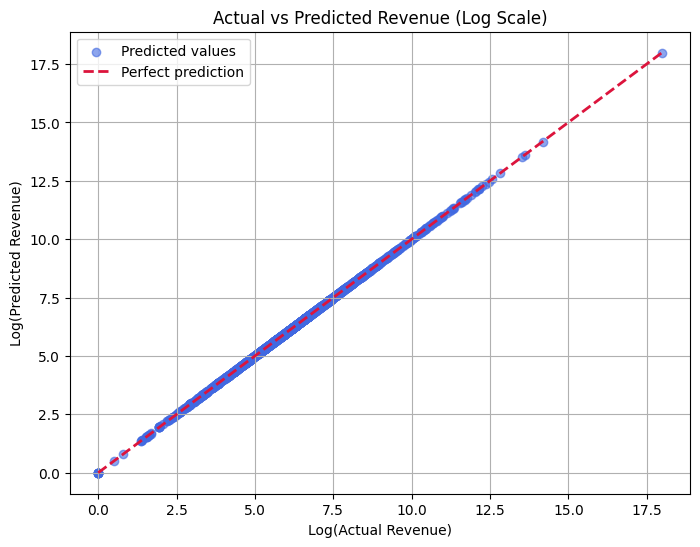

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Convert Decimal → float
y_test_float = y_test.astype(float)
y_pred_float = y_pred.astype(float)

plt.figure(figsize=(8,6))

# Predicted vs Actual points
plt.scatter(
    np.log1p(y_test_float),
    np.log1p(y_pred_float),
    color="royalblue",
    alpha=0.6,
    label="Predicted values"
)

# Reference diagonal line (Actual = Predicted)
min_val = min(np.log1p(y_test_float).min(), np.log1p(y_pred_float).min())
max_val = max(np.log1p(y_test_float).max(), np.log1p(y_pred_float).max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Log(Actual Revenue)")
plt.ylabel("Log(Predicted Revenue)")
plt.title("Actual vs Predicted Revenue (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()


## **ML Flow 2 - Segmentation(K-means Clustering)**

In [0]:
df = spark.read.table("liquid_telecom.gold.g_fact_subscriptions_revenue")

In [0]:
cluster_features = [
    "total_one_off_price_usd",
    "total_recurring_price_usd",
    "total_revenue_usd"
]

In [0]:
pdf_cluster = df.select(cluster_features).toPandas()
pdf_cluster = pdf_cluster.dropna()


In [0]:
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=3, random_state=42)
pdf_cluster["cluster"] = kmeans_model.fit_predict(pdf_cluster)


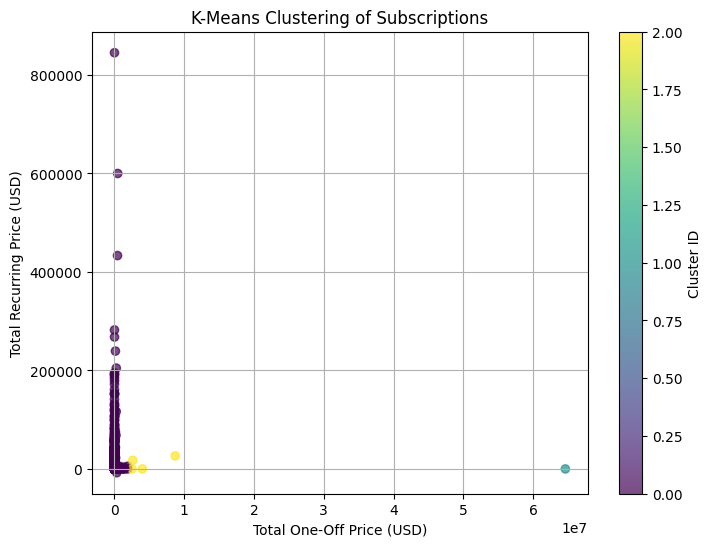

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    pdf_cluster["total_one_off_price_usd"],
    pdf_cluster["total_recurring_price_usd"],
    c=pdf_cluster["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Total One-Off Price (USD)")
plt.ylabel("Total Recurring Price (USD)")
plt.title("K-Means Clustering of Subscriptions")
plt.colorbar(label="Cluster ID")
plt.grid(True)
plt.show()


In [0]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="Subscription_Segmentation_KMeans"):
    mlflow.log_param("model_type", "KMeans")
    mlflow.log_param("n_clusters", 3)
    mlflow.sklearn.log_model(kmeans_model, "kmeans_model")


2026/01/30 13:20:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
